<a href="https://colab.research.google.com/github/Amri1003/Deep_Learning_Projects/blob/main/ANN_Using_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build ANN using Pytorch

In [ ]:
# import library
import torch
import numpy as np
import torch.nn as nn # All Neural Networks
import torch.nn.functional as F # Non linear activation functions
import torch.optim as optim # optimation algo
from torchvision import datasets,transforms # download dataset, transform images
from torch.utils.data.sampler import SubsetRandomSampler
print('imported')

imported


# Process
1. Load & Visualize the data
2. PreProcess the data
3. Create Arch using Pytorch
4. Train the model
5. Evaluate the model
6. save and load the model/Test

In [ ]:
transform=transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,),(0.5,),)])

In [ ]:
# Load the data -train and test set
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data', download=True, train=True,transform=transform)
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data', download=True, train=False,transform=transform)
print('Data loaded')

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.87MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]

Data loaded


In [ ]:
print(trainset.data.shape)
print(trainset.targets.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


In [ ]:
print(testset.data.shape)
print(testset.targets.shape)

torch.Size([10000, 28, 28])
torch.Size([10000])


In [ ]:
# infor about trainset
print(trainset.classes)
print(trainset.class_to_idx)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [ ]:
print(trainset)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: /root/.pytorch/F_MNIST_data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


In [ ]:
# dataloader
indices=list(range(len(trainset)))
np.random.shuffle(indices)

#  20% of train set-validation data
split=int(np.floor(0.2*len(trainset)))
train_sample=SubsetRandomSampler(indices[split:])
valid_sample=SubsetRandomSampler(indices[:split])

In [ ]:
print(len(train_sample))
print(len(valid_sample))

48000
12000


In [ ]:
# data loader
trainloader=torch.utils.data.DataLoader(trainset,sampler=train_sample,batch_size=64)
validloader=torch.utils.data.DataLoader(trainset,sampler=valid_sample,batch_size=64)
testloader=torch.utils.data.DataLoader(testset,batch_size=64,shuffle=True)

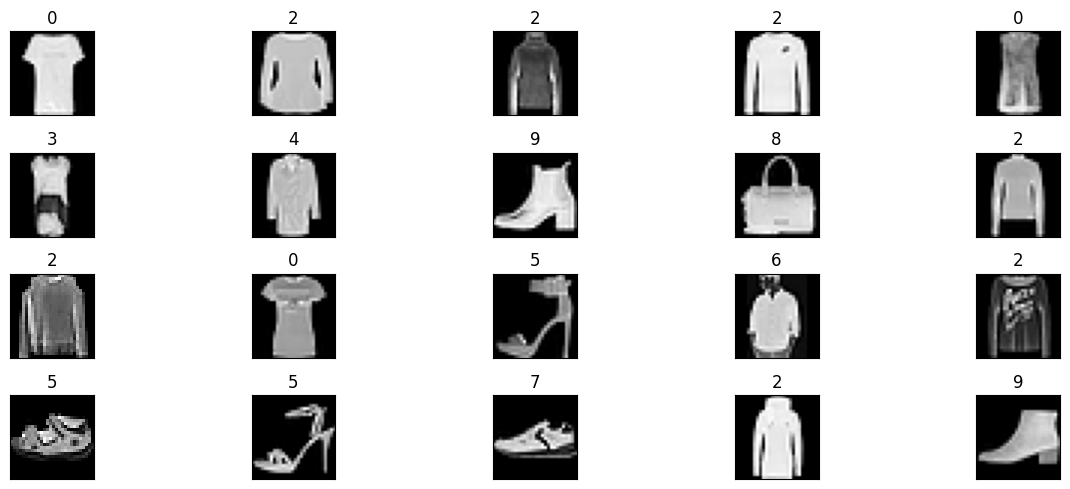

In [ ]:
import matplotlib.pyplot as plt

# get some random training images
dataiter = iter(trainloader)
print(dataiter)
#images, labels = dataiter.next()

images, labels = next(dataiter)

#images, labels = trainloader

fig = plt.figure(figsize=(15,5))
for idx in np.arange(20):
  # xticks=[], yticks=[] is empty to print the images without any ticks around them
  #np.sqeeze : Remove single-dimensional entries from the shape of an array.
  ax = fig.add_subplot(4,5, idx+1, xticks=[], yticks=[])
  ax.imshow(np.squeeze(images[idx]), cmap='gray')
   # .item() gets the value contained in a Tensor
  ax.set_title(labels[idx].item())
  fig.tight_layout()

# Create ANN

# input layer--hidden layer 2--op layer

In [ ]:
class Classifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1=nn.Linear(784,256)
    self.fc2=nn.Linear(256,120)
    self.fc3=nn.Linear(120,10)
    self.dropout=nn.Dropout(p=0.2)

  def forward(self,x):
    x=x.view(x.shape[0],-1)
    x=self.dropout(F.relu(self.fc1(x)))
    x=self.dropout(F.relu(self.fc2(x)))
    #op layer
    x=F.log_softmax(self.fc3(x),dim=1)
    return x

In [ ]:
model=Classifier()
print(model)

Classifier(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


# Compile

In [ ]:
# loss funstion, optimizer
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
#

# training the ANN

In [ ]:
import numpy as np
valid_loss_min=np.inf
epochs=10
steps=0
train_losses,valid_losses=[],[]

In [ ]:
for e in range(epochs):
    running_loss=0
    valid_loss=0
    # to train the model
    for images,labels in trainloader:
        optimizer.zero_grad() # clear the gardients
        log_ps=model(images) # forward pass
        loss=criterion(log_ps,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()*images.size(0)
    for images,labels in validloader:
        log_ps=model(images)
        loss=criterion(log_ps,labels)
        valid_loss+=loss.item()*images.size(0)
    running_loss=running_loss/len(trainloader.sampler)
    valid_loss=valid_loss/len(validloader.sampler)
    train_losses.append(running_loss)
    valid_losses.append(valid_loss)
    print('Epoch:{} \t Training Loss:{:.6f} \t validation Loss:{:.6f}'.
         format(e+1,running_loss,valid_loss))
    if valid_loss <= valid_loss_min:
      print('validation loss decreased({:.6f} -->{:.6f}). Saving Model ...'.format(valid_loss_min, valid_loss))
      torch.save(model.state_dict(), 'model.pt')
      valid_loss_min = valid_loss

Epoch:1 	 Training Loss:0.566557 	 validation Loss:0.458595
validation loss decreased(inf -->0.458595). Saving Model ...
Epoch:2 	 Training Loss:0.418788 	 validation Loss:0.413363
validation loss decreased(0.458595 -->0.413363). Saving Model ...
Epoch:3 	 Training Loss:0.384868 	 validation Loss:0.401548
validation loss decreased(0.413363 -->0.401548). Saving Model ...
Epoch:4 	 Training Loss:0.360229 	 validation Loss:0.412025
Epoch:5 	 Training Loss:0.340675 	 validation Loss:0.375964
validation loss decreased(0.401548 -->0.375964). Saving Model ...
Epoch:6 	 Training Loss:0.328300 	 validation Loss:0.371003
validation loss decreased(0.375964 -->0.371003). Saving Model ...
Epoch:7 	 Training Loss:0.315438 	 validation Loss:0.384585
Epoch:8 	 Training Loss:0.305129 	 validation Loss:0.366678
validation loss decreased(0.371003 -->0.366678). Saving Model ...
Epoch:9 	 Training Loss:0.295615 	 validation Loss:0.359610
validation loss decreased(0.366678 -->0.359610). Saving Model ...
Epo

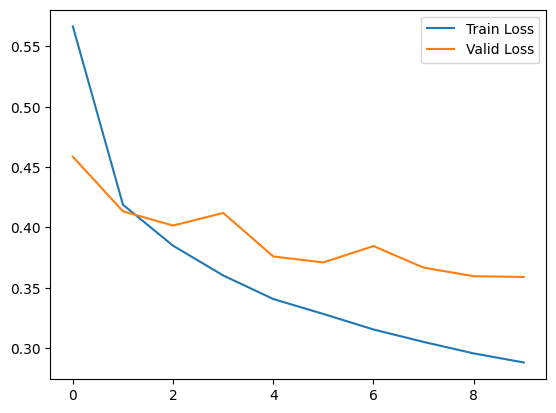

In [ ]:
plt.plot(train_losses,label='Train Loss')
plt.plot(valid_losses,label='Valid Loss')
plt.legend()
plt.show()

In [ ]:
overall_train_loss=np.mean(train_losses)
overall_valid_loss=np.mean(valid_losses)

In [ ]:
print('Overall Train losses',overall_train_loss)
print('Overall Valid losses',overall_valid_loss)

Overall Train losses 0.36036930710077286
Overall Valid losses 0.3902324594219525


# Test the model

In [ ]:
# Set the model to evaluation mode
model.eval()

# Initialize lists to store predictions and labels
predictions = []
true_labels = []

# Iterate through the test data
with torch.no_grad():  # Disable gradient calculation for efficiency
    for images, labels in testloader:
        # Forward pass: get model predictions
        output = model(images)

        # Get the predicted class label (max log-probability)
        _, predicted = torch.max(output, 1)

        # Store predictions and true labels
        predictions.extend(predicted.numpy())
        true_labels.extend(labels.numpy())

In [ ]:
# Convert lists to numpy arrays for further evaluation if needed
predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Print a few predictions and corresponding true labels
print("Predictions: ", predictions[:10])
print("True Labels: ", true_labels[:10])

# You can also compute accuracy or other metrics
accuracy = np.mean(predictions == true_labels)
print(f'Accuracy on test data: {accuracy * 100:.2f}%')

Predictions:  [4 1 8 6 0 1 6 5 6 2]
True Labels:  [4 1 8 6 0 1 6 5 0 2]
Accuracy on test data: 87.65%


In [ ]:
print(testset.class_to_idx)

{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [ ]:
# give prediction code on new image



In [ ]:
model.load_state_dict(torch.load('model.pt'))
model.eval()

Classifier(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

### Prediction on a Single Image

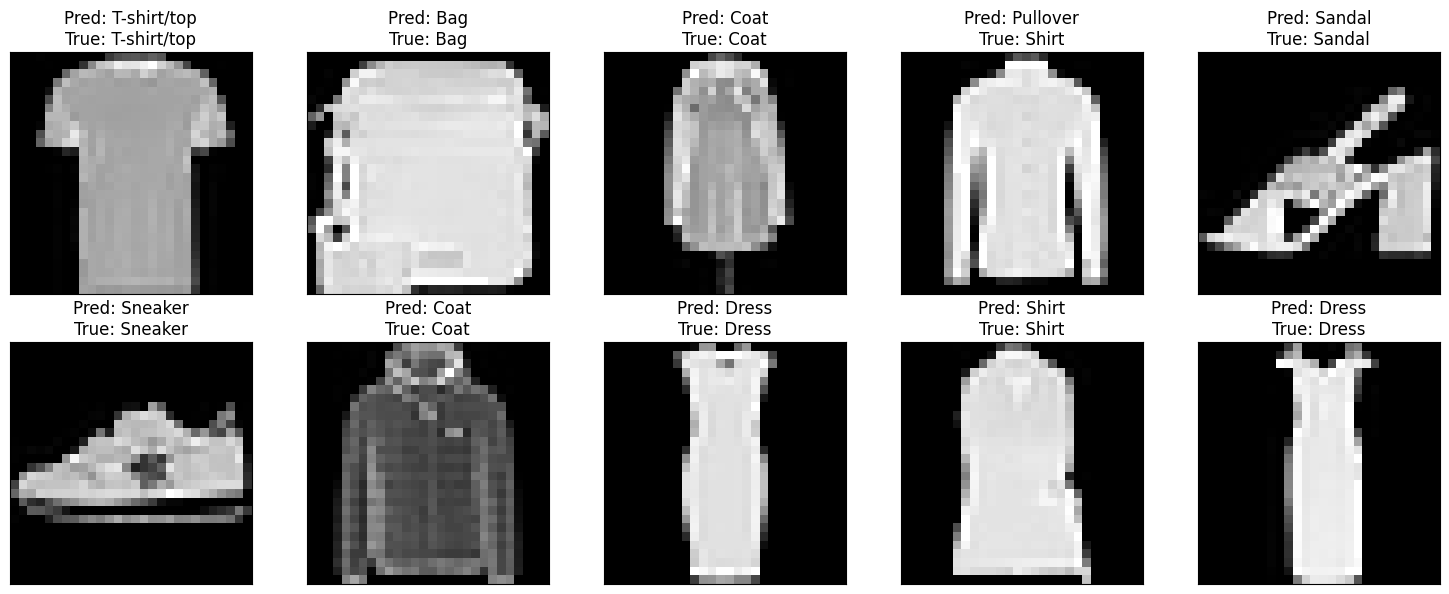

In [ ]:
# Get a batch of images from the test set for demonstration
dataiter = iter(testloader)
images, labels = next(dataiter)

# Make prediction on the batch
with torch.no_grad():
    output = model(images)

# Get probabilities and predicted classes for the batch
probabilities = torch.exp(output)
_, predicted_class_indices = torch.max(probabilities, 1)

# Display the first 10 images with predictions
fig = plt.figure(figsize=(15, 6))
for idx in range(10):
    # Ensure image is in a displayable format (e.g., remove batch dim, convert to numpy)
    img = images[idx].squeeze().numpy() # Squeeze removes single-dimensional entries
    predicted_label = testset.classes[predicted_class_indices[idx].item()]
    true_label_name = testset.classes[labels[idx].item()]

    ax = fig.add_subplot(2, 5, idx + 1, xticks=[], yticks=[])
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Pred: {predicted_label}\nTrue: {true_label_name}')
plt.tight_layout()
plt.show()